In [1]:
import plotly.express as px
import requests
import pandas as pd
import numpy as np
import os
import folium

In [ ]:
# 1. Fetch municipality GeoJSON from DAWA
geojson = requests.get(
    "https://api.dataforsyningen.dk/kommuner?format=geojson"
).json()

# Each feature has properties: "kode" (4-digit code), "navn" (name)
# Extract names and codes for a base dataframe
municipalities = [
    {
        "Municipality" : f["properties"]["navn"],
        "KommuneCode"  : f["properties"]["kode"],
        "RegionName"   : f["properties"]["regionsnavn"],
        "RegionCode"   : f["properties"]["regionskode"]
    }
    for f in geojson["features"]
]
df_mun = pd.DataFrame(municipalities)


In [2]:
df_mun = pd.read_csv("../data/geography/municipalities.csv", encoding="utf-8")

df_stats = pd.read_csv("../data/geography/statsbank_combined.csv", encoding="utf-8")

df_pUnit = pd.read_csv('../data/CVR_API/cvr_production_units_geocoded.csv', encoding='utf-8')
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()

In [17]:
df_pUnit['KommuneCode'].nunique()

99

Removed 33 companies.


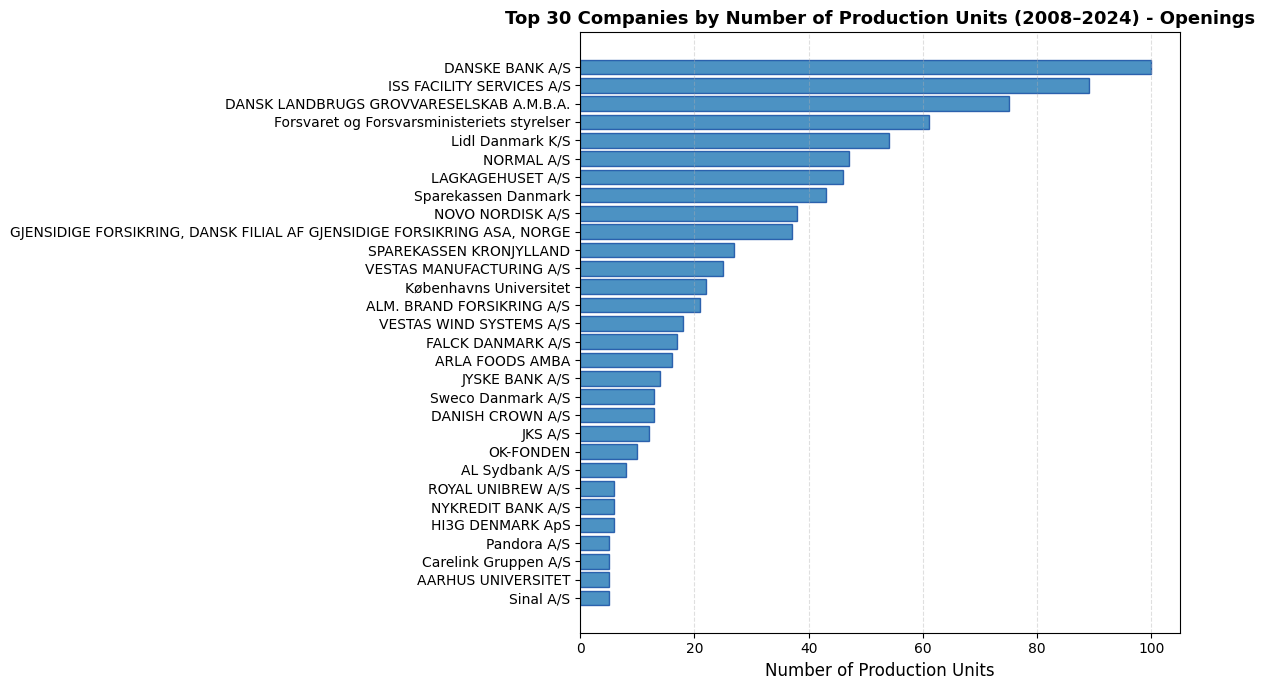

Removed 33 companies.


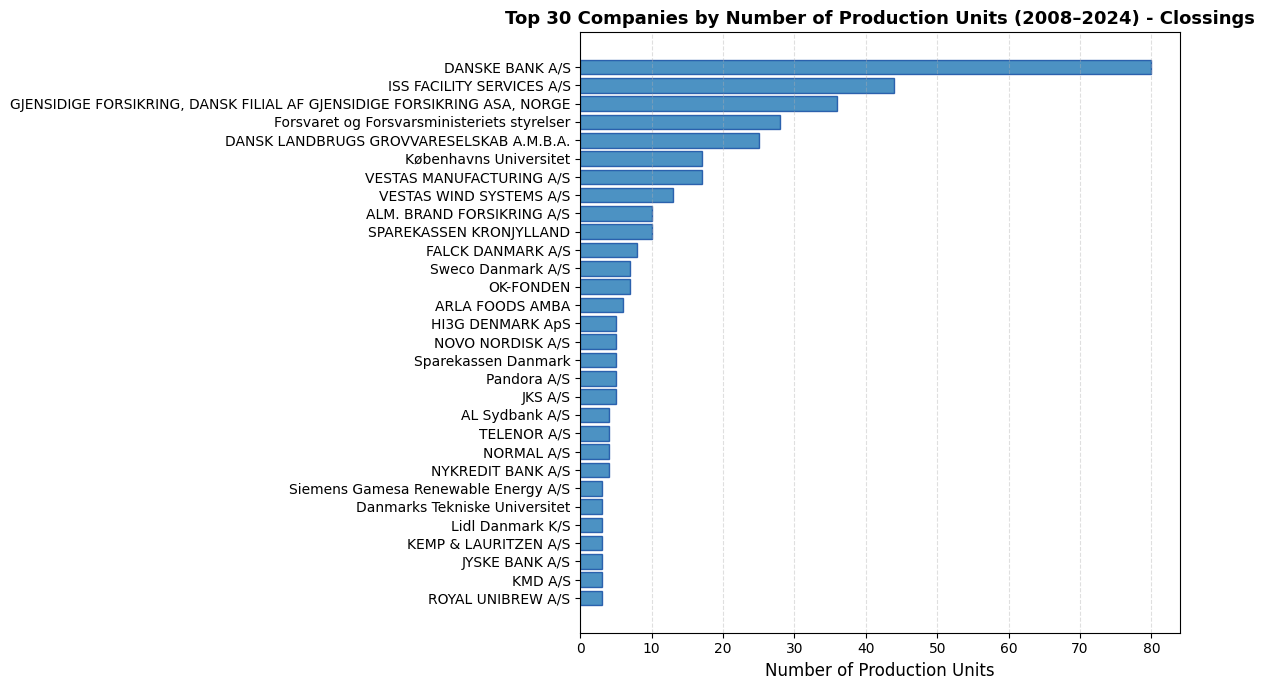

Removed 33 companies.


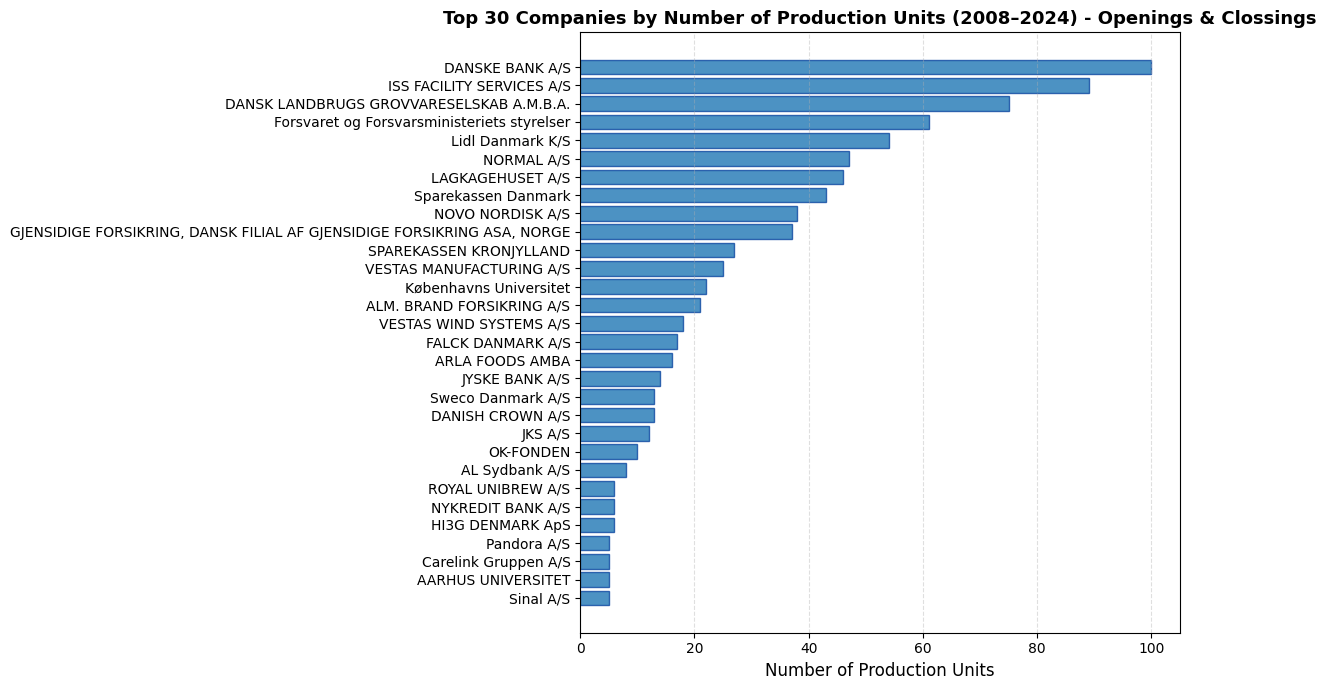

Removed 33 companies.


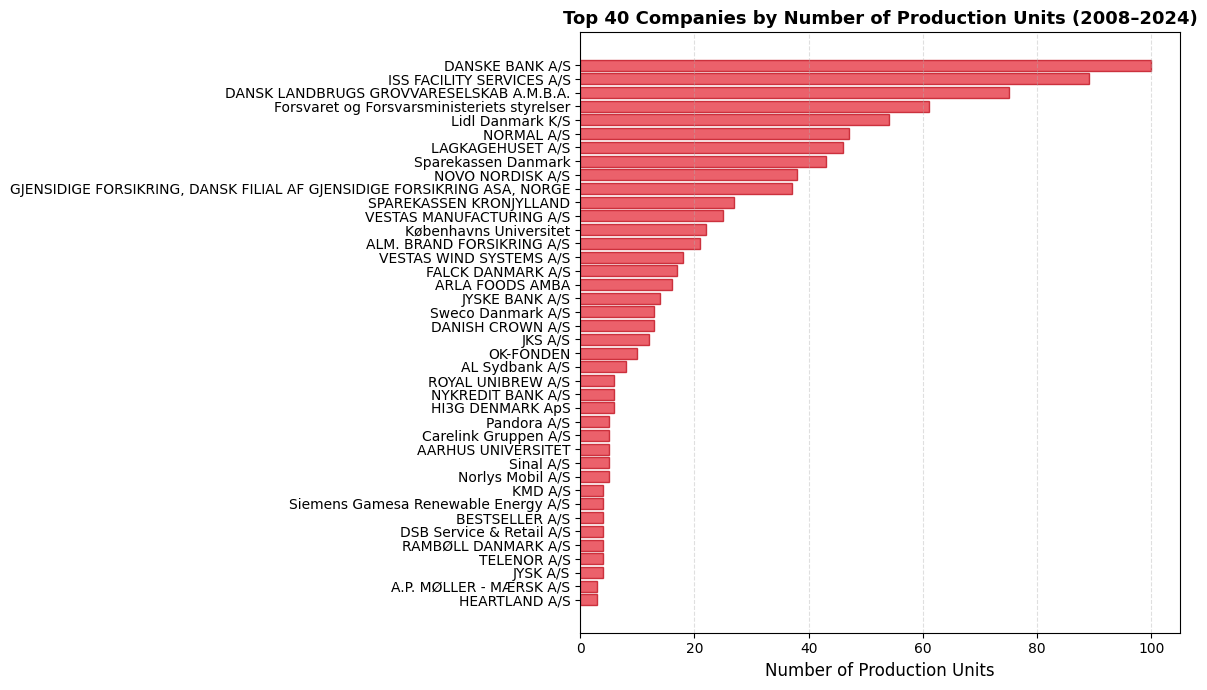

In [16]:
import matplotlib.pyplot as plt

# Select only production units openings from 2008 onwards or closings from 2008 onwards
df_plot_openings = df_plot[
    (df_plot['UnitStartdate'] >= '2008-01-01') | (df_plot['UnitEnddate'] == None)
].copy()

df_plot_open_closings = df_plot[
   (df_plot['UnitStartdate'] >= '2008-01-01') | (df_plot['UnitEnddate'] >= '2008-01-01')
].copy()

df_plot_closings = df_plot[
   (df_plot['UnitStartdate'] < '2008-01-01') | (df_plot['UnitEnddate'] >= '2008-01-01')
].copy()

def plot_company_units(df, title, top_n=30):
    company_counts = (
        df.groupby('CompanyName')
        .size()
        .reset_index(name='UnitCount')
        .sort_values('UnitCount', ascending=False)
    )

    # Remove companies with 'Kommune' in their name (municipalities)
    bf = len(company_counts)
    company_counts = company_counts[~company_counts['CompanyName'].str.contains('Kommune|Region', case=False, na=False)]
    # Remove suppermarkets and retail chains
    company_counts = company_counts[~company_counts['CompanyName'].str.contains('Salling|365discount|COOP|POST|politi|COMPASS', case=False, na=False)]
    print(f"Removed {bf - len(company_counts)} companies.")
    
    
    df_top = company_counts.head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(df_top['CompanyName'][::-1], df_top['UnitCount'][::-1], color='#1f77b4', edgecolor='#0d47a1', alpha=0.8)
    ax.set_xlabel('Number of Production Units', fontsize=12)
    ax.set_title(f'Top {top_n} Companies by Number of Production Units (2008–2024) - {title}', fontsize=13, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

for df, title, n_comp in [
    (df_plot_openings,"Openings", 30),
    (df_plot_closings, "Clossings", 30),
    (df_plot_open_closings, "Openings & Clossings", 30)
    ]:
    plot_company_units(df, title, top_n=n_comp)



# Count production units per company
company_counts = (
    df_plot.groupby('CompanyName')
    .size()
    .reset_index(name='UnitCount')
    .sort_values('UnitCount', ascending=False)
)

# Remove companies with 'Kommune' in their name (municipalities)
bf = len(company_counts)
company_counts = company_counts[~company_counts['CompanyName'].str.contains('Kommune|Region', case=False, na=False)]
# Remove suppermarkets and retail chains
company_counts = company_counts[~company_counts['CompanyName'].str.contains('Salling|365discount|COOP|POST|politi|COMPASS', case=False, na=False)]
print(f"Removed {bf - len(company_counts)} companies.")


# ── Plot top N companies ──────────────────────────────────────────────────────
top_n = 40
df_top = company_counts.head(top_n)


fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_top['CompanyName'][::-1], df_top['UnitCount'][::-1], color='#e63946', edgecolor='#c1121f', alpha=0.8)
ax.set_xlabel('Number of Production Units', fontsize=12)
ax.set_title(f'Top {top_n} Companies by Number of Production Units (2008–2024)', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
#plt.savefig('company_unit_distribution.png', dpi=150)
plt.show()

In [8]:
import folium
import requests
import pandas as pd
import branca.colormap as cm

# 1. Fetch GeoJSON
geojson = requests.get(
    "https://api.dataforsyningen.dk/kommuner?format=geojson"
).json()

# 2. Load income data for 2024
df = pd.read_csv("../data/geography/statsbank_combined.csv")
df_2024 = df[df["year"] == 2024]

# Build a lookup: municipality_code -> average_income
# Keys are strings because GeoJSON "kode" is a string
income_by_code = {
    f"{int(row.municipality_code):04d}": row.average_income
    for row in df_2024.itertuples()
    if pd.notna(row.average_income)
}

# 3. Inject average_income into each GeoJSON feature so the tooltip can show it
for feature in geojson["features"]:
    code = feature["properties"]["kode"]
    income = income_by_code.get(code)
    feature["properties"]["average_income"] = (
        f"{income:,.0f} DKK" if income is not None else "N/A"
    )

# 3. Create a color scale based on the income range
vmin = min(income_by_code.values())
vmax = max(income_by_code.values())
colormap = cm.linear.YlGnBu_09.scale(vmin, vmax)
colormap.caption = "Average income (DKK), 2024"

# 4. Style function: color by income, neutral grey if missing
def style_function(feature):
    code = feature["properties"]["kode"]
    income = income_by_code.get(code)
    fill = colormap(income) if income is not None else "#cccccc"
    return {
        "fillColor": fill,
        "color": "#1a1a2e",
        "weight": 1,
        "fillOpacity": 0.4,
    }

# 5. Create base map
m = folium.Map(
    location=[56.0, 10.5],
    zoom_start=7,
    tiles="CartoDB positron",
)

# 6. Add municipality boundaries with income-based fill and popups
folium.GeoJson(
    geojson,
    name="Municipalities",
    style_function=style_function,
    highlight_function=lambda feature: {
        "fillColor": "#f0a500",
        "fillOpacity": 0.7,
        "weight": 2,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["navn", "kode", "regionsnavn", "average_income"],
        aliases=["Municipality:", "Code:", "Region:", "Average Income:"],
        localize=True,
    ),
).add_to(m)

colormap.add_to(m)
folium.LayerControl().add_to(m)

# Reposition and rotate the colormap legend to bottom-right, vertical
m.get_root().html.add_child(folium.Element("""
<style>
  /* Branca colormap container */
  svg.legend {
    position: fixed !important;
    bottom: 30px !important;
    right: 20px !important;
    top: auto !important;
    left: auto !important;
    transform: rotate(-90deg);
    transform-origin: bottom right;
  }
</style>
"""))

save_name = "test_municipalities_map.html"
m.save(save_name)

In [ ]:
import folium
from folium.plugins import TimeSliderChoropleth
import requests
import pandas as pd
import branca.colormap as cm

# 1. Fetch GeoJSON
geojson = requests.get(
    "https://api.dataforsyningen.dk/kommuner?format=geojson"
).json()

# 2. Load income data for all years
df = pd.read_csv("../data/geography/statsbank_combined.csv")
df = df.dropna(subset=["average_income"]).copy()

# Zero-pad municipality_code to match GeoJSON "kode" ("0101", "0410", etc.)
df["code"] = df["municipality_code"].astype(int).map(lambda c: f"{c:04d}")

# 3. Set feature "id" on the GeoJSON to the municipality code.
#    TimeSliderChoropleth keys its styledict by feature.id, not by a property.
for feature in geojson["features"]:
    feature["id"] = feature["properties"]["kode"]

# 4. Build the color scale across ALL years so colors are comparable over time
vmin = df["average_income"].min()
vmax = df["average_income"].max()
colormap = cm.linear.Reds_08.scale(np.floor(vmin), np.ceil(vmax))
colormap.caption = "Average income (DKK), 2008–2024"

# 5. Build styledict: {code: {timestamp_seconds: {"color": ..., "opacity": ...}}}
#    Timestamps must be UNIX seconds as strings.
styledict = {}
for code, group in df.groupby("code"):
    entries = {}
    for row in group.itertuples():
        ts = str(int(pd.Timestamp(f"{row.year}-01-01").timestamp()))
        entries[ts] = {
            "color": colormap(row.average_income),
            "opacity": 0.7,
        }
    styledict[code] = entries

# 6. Fill missing (code, year) combinations with the neutral grey so the
#    municipality stays visible (and grey) on years it has no data.
all_years = sorted(df["year"].unique())
all_timestamps = [
    str(int(pd.Timestamp(f"{y}-01-01").timestamp())) for y in all_years
]
for feature in geojson["features"]:
    code = feature["id"]
    if code not in styledict:
        styledict[code] = {}
    for ts in all_timestamps:
        styledict[code].setdefault(ts, {"color": "#cccccc", "opacity": 0.7})

# 7. Create base map
m = folium.Map(
    location=[56.0, 10.5],
    zoom_start=7,
    tiles="CartoDB positron",
)

# 8. Add the animated choropleth
TimeSliderChoropleth(
    data=geojson,
    styledict=styledict,
    name="Average income by year",
).add_to(m)

colormap.add_to(m)
folium.LayerControl().add_to(m)
m.save("test_municipalities_animated.html")

AttributeError: 'numpy.float64' object has no attribute 'floor'

In [19]:

from folium.plugins import TimestampedGeoJson
from branca.colormap import linear

# ── 1. Fetch municipality GeoJSON ─────────────────────────────────────────
geojson = requests.get(
    "https://api.dataforsyningen.dk/kommuner?format=geojson"
).json()

# ── 2. Filter df_plot: only units that OPEN or CLOSE during 2008-2024 ────
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()

df_plot = df_plot[~df_plot['CompanyName'].str.contains(
    'Kommune|Region', case=False, na=False)]
df_plot = df_plot[~df_plot['CompanyName'].str.contains(
    'Salling|365discount|COOP|POST|politi|COMPASS', case=False, na=False)]

df_plot['UnitEnddate']   = pd.to_datetime(df_plot['UnitEnddate'], errors='coerce')
df_plot['UnitStartdate'] = pd.to_datetime(
    df_plot['UnitStartdate'].str.replace(' - ', '/', regex=False),
    format='%d/%m/%Y', errors='coerce'
)

PERIOD_START = pd.Timestamp('2008-01-01')
PERIOD_END   = pd.Timestamp('2024-12-31')

opened_in_period = df_plot['UnitStartdate'].between(PERIOD_START, PERIOD_END)
closed_in_period = df_plot['UnitEnddate'].between(PERIOD_START, PERIOD_END)

# Keep only rows where at least one event occurred inside the window
df_plot = df_plot[opened_in_period | closed_in_period].copy()

df_plot['StartYear'] = (
    df_plot['UnitStartdate'].dt.year.fillna(2008)
    .astype(int).clip(lower=2008, upper=2024)
)
df_plot['EndYear'] = (
    df_plot['UnitEnddate'].dt.year.fillna(2024)
    .astype(int).clip(lower=2008, upper=2024)
)

# ── 3. Reconcile municipality codes: int 101 → str '0101' ────────────────
METRIC = 'average_income'    # swap to 'population' if preferred
df_s = df_stats.copy()
df_s['kode'] = df_s['municipality_code'].astype(int).astype(str).str.zfill(4)

# (kode, year) → metric value
stats_lookup = df_s.set_index(['kode', 'year'])[METRIC].to_dict()
stat_years   = sorted(df_s['year'].unique().tolist())

# Continuous red color scale across full metric range
colormap = linear.Reds_09.scale(df_s[METRIC].min(), df_s[METRIC].max())
colormap.caption = METRIC.replace('_', ' ').title()

def color_for(kode, year):
    val = stats_lookup.get((kode, year))
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return '#dddddd'         # gray for missing data
    return colormap(val)

# ── 4. Base map ──────────────────────────────────────────────────────────
m = folium.Map(location=[56.0, 10.5], zoom_start=7, tiles='CartoDB positron')

# ── 5. Polygon features: one per municipality per year ───────────────────
muni_features = []
for feat in geojson['features']:
    kode   = feat['properties'].get('kode')
    navn   = feat['properties'].get('navn', '')
    region = feat['properties'].get('regionsnavn', '')

    for yr in stat_years:
        val = stats_lookup.get((kode, yr))
        muni_features.append({
            "type": "Feature",
            "geometry": feat['geometry'],
            "properties": {
                "times": [f"{yr}-01-01"],
                "style": {
                    "fillColor":   color_for(kode, yr),
                    "color":       "#1a1a2e",
                    "weight":      1,
                    "fillOpacity": 0.6,
                },
                "popup": (
                    f"<b>{navn}</b> ({kode})<br>"
                    f"<b>Region:</b> {region}<br>"
                    f"<b>Year:</b> {yr}<br>"
                    f"<b>{METRIC}:</b> "
                    f"{'N/A' if val is None or pd.isna(val) else f'{val:,.0f}'}"
                ),
            },
        })

# ── 6. Point features: production units ─────────────────────────────────
unit_features = []
for _, row in df_plot.iterrows():
    active_years = list(range(int(row['StartYear']), int(row['EndYear']) + 1))
    times = [f"{yr}-01-01" for yr in active_years]

    unit_features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['Lon'], row['Lat']],
        },
        "properties": {
            "times": times,
            "popup": (
                f"<b>{row['UnitName']}</b><br>"
                f"<b>Company:</b> {row['CompanyName']}<br>"
                f"<b>Address:</b> {row['UnitAddress']}, "
                f"{row['UnitZipcode']} {row['UnitCity']}<br>"
                f"<b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>"
                f"<b>Region:</b> {row['RegionName']}<br>"
                f"<b>Employees:</b> {row['UnitEmployees']}<br>"
                f"<b>Active:</b> {int(row['StartYear'])} – "
                f"{'Open' if pd.isna(row['UnitEnddate']) else int(row['EndYear'])}"
            ),
            "icon": "circle",
            "iconstyle": {
                "fillColor":   "#0a3d62",   # dark blue contrasts with red fills
                "fillOpacity": 0.85,
                "stroke":      True,
                "color":       "#000000",
                "weight":      1,
                "radius":      4,
            },
        },
    })

# ── 7. Combined TimestampedGeoJson ──────────────────────────────────────
TimestampedGeoJson(
    data={"type": "FeatureCollection",
          "features": muni_features + unit_features},
    period="P1Y",
    duration="P1Y",
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options="YYYY",
    time_slider_drag_update=True,
    transition_time=800,
).add_to(m)

colormap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save("denmark_units.html")

In [3]:
import folium, requests, pandas as pd
from datetime import datetime
from branca.colormap import linear
from folium.plugins import TimeSliderChoropleth

# ── 1. Data ──────────────────────────────────────────────────────────────
geojson  = requests.get("https://api.dataforsyningen.dk/kommuner?format=geojson").json()
df_stats = pd.read_csv("../data/geography/statsbank_combined.csv")
df_stats["kode"] = df_stats["municipality_code"].astype(int).astype(str).str.zfill(4)

METRIC = "population"     # ← swap to "average_income" for the second map
YEARS  = range(2008, 2025)

# ── 2. Continuous red colormap, capped at 99th percentile ────────────────
vmin = df_stats[METRIC].min()
vmax = df_stats[METRIC].quantile(0.99)     # keeps KBH / Gentofte from crushing the ramp
cmap = linear.Reds_09.scale(vmin, vmax)
cmap.caption = METRIC.replace("_", " ").title()

# ── 3. Tell TimeSliderChoropleth which feature is which (id = kode) ──────
for f in geojson["features"]:
    f["id"] = f["properties"]["kode"]

# ── 4. styledict — analogue of your style_function, but keyed by year ───
lookup = df_stats.set_index(["kode", "year"])[METRIC].to_dict()
styledict = {}
for f in geojson["features"]:
    kode = f["id"]
    styledict[kode] = {}
    for year in YEARS:
        ts  = str(int(datetime(year, 1, 1).timestamp()))
        val = lookup.get((kode, year))
        color = "#dddddd" if val is None or pd.isna(val) else cmap(min(val, vmax))
        styledict[kode][ts] = {"color": color, "opacity": 0.7}

# ── 5. Map + slider ──────────────────────────────────────────────────────
m = folium.Map(location=[56.0, 10.5], zoom_start=7, tiles="CartoDB positron")

TimeSliderChoropleth(
    data=geojson,
    styledict=styledict,
    init_timestamp=-1,       # start on the latest year (2024)
).add_to(m)

cmap.add_to(m)
m.save(f"denmark_{METRIC}.html")

In [ ]:
import requests

# 1. Fetch GeoJSON
geojson = requests.get(
    "https://api.dataforsyningen.dk/kommuner?format=geojson"
).json()

# 2. Create base map centered on Denmark
m = folium.Map(
    location=[56.0, 10.5],
    zoom_start=7,
    tiles="CartoDB positron"
)

# 3. Add municipality boundaries with popups
folium.GeoJson(
    geojson,
    name="Municipalities",
    style_function=lambda feature: {
        "fillColor": "#cc2929",
        "color": "#1a1a2e",
        "weight": 1,
        "fillOpacity": 0.4,
    },
    highlight_function=lambda feature: {
        "fillColor": "#f0a500",
        "fillOpacity": 0.7,
        "weight": 2,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["navn", "kode", "regionsnavn"],
        aliases=["Municipality:", "Code:", "Region:"],
        localize=True,
    ),
).add_to(m)

folium.LayerControl().add_to(m)
#m.save("municipalities.html")   # open in browser
m                                # renders inline in Jupyter

In [15]:
# Region colour palette
region_colors = {
    "Region Hovedstaden" : "#e63946",
    "Region Midtjylland" : "#2a9d8f",
    "Region Syddanmark"  : "#e9c46a",
    "Region Nordjylland" : "#457b9d",
    "Region Sjælland"    : "#8338ec",
}

def style_function(feature):
    region = feature["properties"].get("regionsnavn", "")
    return {
        "fillColor"  : region_colors.get(region, "#cccccc"),
        "color"      : "#1a1a2e",
        "weight"     : 1,
        "fillOpacity": 0.4,
    }

def highlight_function(feature):
    region = feature["properties"].get("regionsnavn", "")
    return {
        "fillColor"  : region_colors.get(region, "#aaaaaa"),
        "fillOpacity": 0.7,
        "weight"     : 2,
    }

# Base map
m = folium.Map(location=[56.0, 10.5], zoom_start=7, tiles="CartoDB positron")

# Municipality boundaries coloured by region
folium.GeoJson(
    geojson,
    name="Municipalities",
    style_function    = style_function,
    highlight_function= highlight_function,
    tooltip=folium.GeoJsonTooltip(
        fields=  ["navn",          "kode",    "regionsnavn"],
        aliases= ["Municipality:", "Code:",   "Region:"],
        localize=True,
    ),
).add_to(m)

# ── Region legend ─────────────────────────────────────────────────────────────
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.3); font-family: sans-serif; font-size: 13px;">
  <b>Region</b><br>
""" + "".join([
    f'<span style="display:inline-block;width:14px;height:14px;'
    f'background:{color};border-radius:50%;margin-right:6px;vertical-align:middle;"></span>'
    f'{region}<br>'
    for region, color in region_colors.items()
]) + "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

save_name = "regions_municipalities.html"
m.save(save_name)
print(f"Saved → {save_name}")

Saved → regions_municipalities.html


In [14]:
from folium.plugins import TimestampedGeoJson

df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()

df_plot = df_plot[~df_plot['CompanyName'].str.contains('Kommune|Region', case=False, na=False)]
# Remove suppermarkets and retail chains
df_plot = df_plot[~df_plot['CompanyName'].str.contains('Salling|365discount|COOP|POST|politi|COMPASS', case=False, na=False)]


df_plot['UnitEnddate'] = pd.to_datetime(df_plot['UnitEnddate'], errors='coerce')
df_plot['UnitStartdate'] = pd.to_datetime(
    df_plot['UnitStartdate'].str.replace(' - ', '/', regex=False),
    format='%d/%m/%Y',
    errors='coerce'
)

current_year = 2024

df_plot['StartYear'] = (
    df_plot['UnitStartdate'].dt.year
    .fillna(2008)
    .astype(int)
    .clip(lower=2008)
)

df_plot['EndYear'] = (
    df_plot['UnitEnddate'].dt.year
    .fillna(current_year)
    .astype(int)
)
# ── 2. Build GeoJSON features — one entry per (unit × active year) ────────────
# TimestampedGeoJson needs each feature to carry a 'times' list with one
# timestamp per "frame" the feature should appear in.

# Base map
m = folium.Map(location=[56.0, 10.5], zoom_start=7, tiles="CartoDB positron")


features = []

for _, row in df_plot.iterrows():
    active_years = list(range(int(row['StartYear']), int(row['EndYear']) + 1))
    times        = [f"{yr}-01-01" for yr in active_years]   # ISO date per year

    feature = {
        "type": "Feature",
        "geometry": {
            "type"       : "Point",
            "coordinates": [row['Lon'], row['Lat']]          # GeoJSON is [lon, lat]
        },
        "properties": {
            "times"  : times,
            "popup"  : (
                f"<b>{row['UnitName']}</b><br>"
                f"<b>Company:</b> {row['CompanyName']}<br>"
                f"<b>Address:</b> {row['UnitAddress']}, {row['UnitZipcode']} {row['UnitCity']}<br>"
                f"<b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>"
                f"<b>Region:</b> {row['RegionName']}<br>"
                f"<b>Employees:</b> {row['UnitEmployees']}<br>"
                f"<b>Active:</b> {int(row['StartYear'])} – "
                f"{'Open' if pd.isna(row['UnitEnddate']) else int(row['EndYear'])}"
            ),
            "icon"   : "circle",
            "iconstyle": {
                "fillColor"  : "#e63946",
                "fillOpacity": 0.3,
                "stroke"     : True,
                "color"      : "#c1121f",
                "weight"     : 1,
                "radius"     : 1.3,
            }
        }
    }
    features.append(feature)

# ── 3. Add TimestampedGeoJson to map ─────────────────────────────────────────
TimestampedGeoJson(
    data           = {"type": "FeatureCollection", "features": features},
    period         = "P1Y",
    duration       = "P1Y",
    auto_play      = False,
    loop           = False,
    max_speed      = 1,          # slowest speed multiplier
    loop_button    = True,
    date_options   = "YYYY",
    time_slider_drag_update = True,
    transition_time = 800,      # ← ms between frames (2000 = 2 seconds per year)
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
#m.save("municipalities_animated.html")
#print("Saved → municipalities_animated.html")

In [24]:
company_geojsons = {}
all_companies    = sorted(df_plot['CompanyName'].dropna().unique().tolist())

for company in all_companies:
    df_company = df_plot[df_plot['CompanyName'] == company]
    feats      = []
    for _, row in df_company.iterrows():
        active_years = list(range(int(row['StartYear']), int(row['EndYear']) + 1))
        times        = [f"{yr}-01-01T00:00:00" for yr in active_years]
        feats.append({
            "type"    : "Feature",
            "geometry": {"type": "Point", "coordinates": [row['Lon'], row['Lat']]},
            "properties": {
                "times"   : times,
                "popup"   : (
                    f"<b>{row['UnitName']}</b><br>"
                    f"<b>Company:</b> {row['CompanyName']}<br>"
                    f"<b>Address:</b> {row['UnitAddress']}, {row['UnitZipcode']} {row['UnitCity']}<br>"
                    f"<b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>"
                    f"<b>Region:</b> {row['RegionName']}<br>"
                    f"<b>Employees:</b> {row['UnitEmployees']}<br>"
                    f"<b>Active:</b> {int(row['StartYear'])} – "
                    f"{'Open' if pd.isna(row['UnitEnddate']) else int(row['EndYear'])}"
                ),
            }
        })
    company_geojsons[company] = {"type": "FeatureCollection", "features": feats}

# "All" option
all_features = []
for feats in company_geojsons.values():
    all_features.extend(feats["features"])
company_geojsons["— All Companies —"] = {"type": "FeatureCollection", "features": all_features}
all_companies = ["— All Companies —"] + all_companies

# ── 2. Build base Folium map (NO TimestampedGeoJson plugin) ──────────────────
m = folium.Map(location=[56.0, 10.5], zoom_start=7, tiles="CartoDB positron")

# Municipality boundaries
folium.GeoJson(
    geojson,
    name="Municipalities",
    style_function    = style_function,
    highlight_function= highlight_function,
    tooltip=folium.GeoJsonTooltip(
        fields=  ["navn", "kode", "regionsnavn"],
        aliases= ["Municipality:", "Code:", "Region:"],
        localize=True,
    ),
).add_to(m)

map_name = m.get_name()

# ── 3. Inject TimeDimension manually + dropdown ───────────────────────────────
companies_js     = json.dumps(company_geojsons, ensure_ascii=False)
dropdown_options = "\n".join(
    [f'<option value="{c}">{c}</option>' for c in all_companies]
)

custom_html = f"""
<!-- TimeDimension CSS & JS -->
<link rel="stylesheet"
      href="https://cdnjs.cloudflare.com/ajax/libs/leaflet-timedimension/1.1.1/leaflet.timedimension.control.min.css"/>
<script src="https://cdnjs.cloudflare.com/ajax/libs/leaflet-timedimension/1.1.1/leaflet.timedimension.min.js"></script>

<!-- Company filter dropdown -->
<div id="company-filter" style="position:fixed; top:80px; right:10px; z-index:9999;
     background:white; padding:12px 16px; border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.3); font-family:sans-serif;
     font-size:13px; max-width:280px;">
    <b>Filter by Company</b><br><br>
    <input id="companySearch" type="text" placeholder="Search company..."
           oninput="filterDropdown(this.value)"
           style="width:100%; padding:6px; border-radius:4px;
                  border:1px solid #ccc; font-size:12px; margin-bottom:6px; box-sizing:border-box;"/>
    <select id="companySelect" size="8" onchange="updateLayer(this.value)"
            style="width:100%; padding:4px; border-radius:4px;
                   border:1px solid #ccc; font-size:12px;">
        {dropdown_options}
    </select>
</div>

<script>
var allCompanyData  = {companies_js};
var allOptions      = Array.from(document.getElementById("companySelect").options).map(o => o.value);
var currentTDLayer  = null;
var timeDimension   = null;
var tdControl       = null;
var mapObj          = null;

// ── Filter dropdown by search input ──────────────────────────────────────────
function filterDropdown(query) {{
    var sel      = document.getElementById("companySelect");
    var filtered = allOptions.filter(o => o.toLowerCase().includes(query.toLowerCase()));
    sel.innerHTML = filtered.map(o => `<option value="${{o}}">${{o}}</option>`).join("");
}}

// ── Swap TimeDimension layer on company selection ─────────────────────────────
function updateLayer(companyName) {{
    if (!companyName) return;

    var geojsonData = allCompanyData[companyName];
    if (!geojsonData) return;

    // Remove existing TD layer
    if (currentTDLayer) {{
        mapObj.removeLayer(currentTDLayer);
        currentTDLayer = null;
    }}

    // Remove existing TD control
    if (tdControl) {{
        mapObj.removeControl(tdControl);
        tdControl = null;
    }}

    // Remove existing timeDimension
    if (mapObj.timeDimension) {{
        delete mapObj.timeDimension;
    }}

    // Collect all unique timestamps from this company's features
    var times = [];
    geojsonData.features.forEach(function(f) {{
        (f.properties.times || []).forEach(function(t) {{
            if (!times.includes(t)) times.push(t);
        }});
    }});
    times.sort();

    if (times.length === 0) return;

    // Create new TimeDimension with this company's time range
    mapObj.timeDimension = L.timeDimension({{
        times          : times,
        currentTime    : new Date(times[0]).getTime(),
    }});

    // Add TD control (slider)
    tdControl = L.control.timeDimension({{
        player: {{
            transitionTime : 1500,
            loop           : false,
            startOver      : true,
        }},
        timeZones          : ["Local"],
        autoPlay           : false,
        loopButton         : true,
        timeSliderDragUpdate: true,
        speedSlider        : false,
        playerOptions      : {{ buttonType: "play" }},
    }});
    tdControl.addTo(mapObj);

    // Build GeoJSON layer with circle markers
    var geoLayer = L.geoJson(geojsonData, {{
        pointToLayer: function(feature, latlng) {{
            return L.circleMarker(latlng, {{
                radius      : 2,
                fillColor   : "#e63946",
                color       : "#c1121f",
                weight      : 1,
                fillOpacity : 0.3,
            }});
        }},
        onEachFeature: function(feature, layer) {{
            if (feature.properties.popup) {{
                layer.bindPopup(feature.properties.popup);
            }}
        }}
    }});

    // Wrap in TimeDimension GeoJSON layer
    currentTDLayer = L.timeDimension.layer.geoJson(geoLayer, {{
        updateTimeDimension         : false,
        waitForReady                : true,
        updateTimeDimensionMode     : "replace",
        addlastPoint                : false,
        duration                    : "P1Y",
    }});

    currentTDLayer.addTo(mapObj);
}}

// ── Init after DOM ready ──────────────────────────────────────────────────────
document.addEventListener("DOMContentLoaded", function() {{
    mapObj = window["{map_name}"];

    // Small delay to ensure Leaflet is fully initialised
    setTimeout(function() {{
        var sel = document.getElementById("companySelect");
        sel.value = "— All Companies —";
        updateLayer("— All Companies —");
    }}, 500);
}});
</script>
"""

m.get_root().html.add_child(folium.Element(custom_html))
save_name = "JS_municipalities_animated.html"
m.save(save_name)
print(f"Saved → {save_name}")

Saved → JS_municipalities_animated.html


In [ ]:
from folium.plugins import MarkerCluster

df_pUnit = pd.read_csv('../data/CVR_API/cvr_production_units_geocoded.csv', encoding='utf-8')
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()


region_groups   = {}
region_clusters = {}

for kommune in sorted(df_plot['KommuneName'].dropna().unique()):
    group   = folium.FeatureGroup(name=f"📍 {kommune}", show=True)
    cluster = MarkerCluster(options={"maxClusterRadius": 40})
    cluster.add_to(group)
    region_groups[kommune]   = group
    region_clusters[kommune] = cluster

no_region_group   = folium.FeatureGroup(name="📍 Kommune Unknown", show=True)
no_region_cluster = MarkerCluster(options={"maxClusterRadius": 40})
no_region_cluster.add_to(no_region_group)

for _, row in df_plot.iterrows():
    popup_html = f"""
        <b>{row['UnitName']}</b><br>
        <b>Company:</b> {row['CompanyName']}<br>
        <b>Address:</b> {row['UnitAddress']}, {row['UnitZipcode']} {row['UnitCity']}<br>
        <b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>
        <b>Region:</b> {row['RegionName']} ({row['RegionCode']})<br>
        <b>Employees:</b> {row['UnitEmployees']}<br>
        <b>Start:</b> {row['UnitStartdate']}<br>
        <b>End:</b> {row['UnitEnddate'] if pd.notna(row['UnitEnddate']) else 'Active'}
    """
    marker = folium.CircleMarker(
        location     = [row['Lat'], row['Lon']],
        radius       = 5,
        color        = "#e63946",
        fill         = True,
        fill_color   = "#e63946",
        fill_opacity = 0.7,
        popup        = folium.Popup(popup_html, max_width=300),
        tooltip      = row['UnitName']
    )

    kommune = row['KommuneName']
    if pd.notna(kommune) and kommune in region_clusters:
        marker.add_to(region_clusters[kommune])
    else:
        marker.add_to(no_region_cluster)

for group in region_groups.values():
    group.add_to(m)
no_region_group.add_to(m)

In [ ]:
df_pUnit = pd.read_csv('../data/CVR_API/cvr_production_units_geocoded.csv', encoding='utf-8')
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()

region_groups = {}
for region in sorted(df_plot['KommuneName'].dropna().unique()):
    group = folium.FeatureGroup(name=f"{region}", show=True)
    region_groups[region] = group

# Catch-all group for units with no region resolved
no_region_group = folium.FeatureGroup(name="Region Unknown", show=True)

for _, row in df_plot.iterrows():
    popup_html = f"""
        <b>{row['UnitName']}</b><br>
        <b>Company:</b> {row['CompanyName']}<br>
        <b>Address:</b> {row['UnitAddress']}, {row['UnitZipcode']} {row['UnitCity']}<br>
        <b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>
        <b>Region:</b> {row['RegionName']} ({row['RegionCode']})<br>
        <b>Employees:</b> {row['UnitEmployees']}<br>
        <b>Start:</b> {row['UnitStartdate']}<br>
        <b>End:</b> {row['UnitEnddate'] if pd.notna(row['UnitEnddate']) else 'Active'}
    """
    marker = folium.CircleMarker(
        location   = [row['Lat'], row['Lon']],
        radius     = 6,
        color      = "#e63946",
        fill       = True,
        fill_color = "#e63946",
        fill_opacity = 0.7,
        popup      = folium.Popup(popup_html, max_width=300),
        tooltip    = row['UnitName']
    )

    region = row['KommuneName']
    if pd.notna(region) and region in region_groups:
        marker.add_to(region_groups[region])
    else:
        marker.add_to(no_region_group)

# Add all groups to map
for group in region_groups.values():
    group.add_to(m)
no_region_group.add_to(m)

# 6. Layer control (enables show/hide per region)
folium.LayerControl(collapsed=False).add_to(m)

save_name = "companies_markers.html"
m.save(save_name)
print(f"Saved → {save_name}")
